# MACHINE LEARNING 

## 1. Análisis de Variables para Predicción de Default P2P


### 1.1 Resumen Ejecutivo

Se seleccionaron **23 variables** para predecir el riesgo de default en préstamos P2P, excluyendo aquellas con potencial sesgo futuro o que requieren ingeniería adicional.

---


### 1.2 Definición de Variables a Utilizar

**Total de variables predictoras:** 23  
**Variable objetivo:** `DEFAULT` (1: Default, 0: No Default)




#### 1.2.1 Capacidad de Pago (8 variables)

| Variable | Descripción |
|----------|-------------|
| `DebtToIncome` | Ratio deuda/ingreso - Mide sobreendeudamiento |
| `FreeCash` | Ingreso discrecional - Capacidad real de pago |
| `IncomeTotal` | Ingreso total - Base de capacidad de pago |
| `ExistingLiabilities` | Número de pasivos - Carga financiera actual |
| `LiabilitiesTotal` | Monto total de pasivos - Carga financiera en € |
| `MonthlyPayment` | Cuota mensual del préstamo - Compromiso adquirido |
| `AppliedAmount` | Monto solicitado - Intención de deuda |
| `Amount` | Monto recibido - Deuda real contraída |




#### 1.2.2 Historial Previo (3 variables)

| Variable | Descripción |
|----------|-------------|
| `NoOfPreviousLoansBeforeLoan` | Experiencia crediticia previa |
| `AmountOfPreviousLoansBeforeLoan` | Historial de endeudamiento |
| `PreviousEarlyRepaymentsCountBeforeLoan` | Buen pagador (señal positiva) |



#### 1.2.3 Rating de Riesgo (1 variable)

| Variable | Descripción |
|----------|-------------|
| `Rating` | Score interno de riesgo (1=mejor, 10=peor) |




#### 1.2.4 Estabilidad Personal (7 variables)

| Variable | Descripción |
|----------|-------------|
| `Age` | Edad - Jóvenes = más riesgo |
| `EmploymentStatus` | Situación laboral - Desempleado = alto riesgo |
| `EmploymentDurationCurrentEmployer` | Antigüedad laboral |
| `HomeOwnershipType` | Tipo de vivienda - Propietario = menos riesgo |
| `MaritalStatus` | Estado civil - Soltero = más riesgo |
| `Education` | Nivel educativo - Mayor educación = menos riesgo |
| `VerificationType` | Verificación de ingresos - Verificado = menos riesgo |




#### 1.2.5 Términos del Préstamo (3 variables)

| Variable | Descripción |
|----------|-------------|
| `Interest` | Tasa de interés - Alta = compensa riesgo |
| `LoanDuration` | Duración en meses - Mayor plazo = más incertidumbre |
| `MonthlyPaymentDay` | Día de pago - Días extremos = más estrés |

---


### 1.3 Justificación por Categoría



#### 1.3.1 Capacidad de Pago

**Por qué se usan:**
- Son las variables más importantes en cualquier modelo de riesgo crediticio
- Miden directamente la habilidad del prestatario para pagar
- `DebtToIncome` es el estándar de la industria bancaria

**Qué predicen:**
- Si el prestatario ya está sobreendeudado (DTI alto)
- Si tiene margen para asumir una nueva cuota (FreeCash bajo)
- Si sus ingresos son suficientes (IncomeTotal bajo)



#### 1.3.2 Historial Previo

**Por qué se usan:**
- El comportamiento pasado es el mejor predictor del futuro
- Prestatarios con reembolsos anticipados son menos riesgosos

**Qué predicen:**
- Si el prestatario ha manejado bien préstamos anteriores
- Si tiene experiencia crediticia o es nuevo
- La consistencia en el comportamiento de pago



#### 1.3.3 Rating

**Por qué se usan:**
- Es un score experto diseñado específicamente para default
- Condensa información compleja en una sola variable

**Qué predicen:**
- La evaluación profesional del riesgo
- Complementa las variables individuales




#### 1.3.4 Estabilidad Personal

**Por qué se usan:**
- Factores demográficos correlacionados con estabilidad financiera
- Validados en múltiples estudios de riesgo crediticio

**Qué predicen:**
- Empleo estable → ingresos predecibles → menos default
- Propietario de vivienda → arraigo → menos default
- Mayor educación → mejores decisiones financieras



#### 1.3.5 Términos del Préstamo

**Por qué se usan:**
- Las características del préstamo afectan la probabilidad de pago
- La tasa de interés refleja el riesgo percibido

**Qué predicen:**
- Plazos largos → más oportunidades de impago
- Tasas altas → prestatarios de mayor riesgo
- Día de pago → posible estrés de liquidez

---


### 1.4 Importancia Esperada por Variable

| Nivel | Variables |
|-------|-----------|
| **CRÍTICA (20-30%)** | `DebtToIncome`, `Rating`, `FreeCash` |
| **ALTA (10-20%)** | `PreviousEarlyRepaymentsCountBeforeLoan`, `IncomeTotal`, `EmploymentStatus`, `ExistingLiabilities` |
| **MEDIA (5-10%)** | `Age`, `LoanDuration`, `Interest`, `MonthlyPayment`, `HomeOwnershipType`, `VerificationType` |
| **BAJA (<5%)** | `Amount`, `MaritalStatus`, `Education`, `MonthlyPaymentDay`, `EmploymentDurationCurrentEmployer`, `AmountOfPreviousLoansBeforeLoan` |

---


### 1.5 Verificación de Supuestos

| Supuesto | Estado | Explicación |
|----------|--------|-------------|
| Disponibilidad temporal | ✅ CUMPLE | Todas las variables están disponibles al momento del desembolso |
| Sin leakage | ✅ CUMPLE | No se incluyen variables post-default |
| Datos completos | ⚠️ PARCIAL | Algunas variables tienen nulos - requieren imputación |
| Escalas adecuadas | ⚠️ PARCIAL | Requieren normalización (ingresos, montos) |
| Multicolinealidad | ⚠️ POSIBLE | `AppliedAmount` y `Amount` están correlacionadas |




#### 1.5.1 Recomendaciones

| # | Recomendación |
|---|---------------|
| 1 | Eliminar `Amount` o `AppliedAmount` (redundantes) |
| 2 | Aplicar `StandardScaler` o `RobustScaler` |
| 3 | Imputar nulos en `EmploymentDurationCurrentEmployer` con mediana |
| 4 | Verificar correlación entre `Rating` y otras variables |

---


### 1.6 Resumen Final

#### 1.6.1 Estadísticas

| Métrica | Valor |
|---------|-------|
| Total de variables | 23 |
| Capacidad de pago | 8 variables |
| Historial previo | 3 variables |
| Rating | 1 variable |
| Estabilidad personal | 7 variables |
| Términos del préstamo | 3 variables |




#### 1.6.2 Top 5 variables más importantes (teóricamente)

| # | Variable | Razón |
|---|----------|-------|
| 1 | `DebtToIncome` | Capacidad de endeudamiento |
| 2 | `Rating` | Score experto de riesgo |
| 3 | `FreeCash` | Margen financiero real |
| 4 | `PreviousEarlyRepaymentsCountBeforeLoan` | Historial positivo |
| 5 | `EmploymentStatus` | Estabilidad laboral |




#### 1.6.3 Variables excluidas (con justificación)

| Variable | Razón de exclusión |
|----------|-------------------|
| `Status`, `DefaultDate`, `PrincipalRecovery` | Leakage temporal (post-default) |
| `BidsPortfolioManager`, `BidsApi`, `BidsManual` | Lado del inversor, no del prestatario |
| `PlannedInterestTillDate`, `PrincipalPaymentsMade` | Requieren tiempo transcurrido |
| `City`, `Country`, `LanguageCode` | Riesgo de sesgo geográfico |



#### 1.6.4 Próximos pasos

| # | Paso | Descripción |
|---|------|-------------|
| 1 | Análisis de correlación | Verificar correlación real con los datos |
| 2 | Ingeniería de features | Crear `Payment/Income`, `Amount/Income` |
| 3 | División temporal | Train anterior, test posterior |
| 4 | Modelo baseline | Logistic Regression, XGBoost, Random Forest |

---

### 1.7 Conclusión

La selección de **23 variables** cubre todas las dimensiones relevantes para la predicción de default: capacidad de pago, historial crediticio, perfil demográfico y términos del préstamo. Las variables excluidas evitaron leakage temporal y sesgos geográficos. El siguiente paso es validar estas hipótesis con análisis de correlación y modelado predictivo.

## 2. Analisis EDA

### Descripción de la Sección

El Análisis Exploratorio de Datos (EDA) es la primera fase del modelado, donde se busca **comprender la estructura, calidad y características** del dataset antes de aplicar cualquier técnica de machine learning. Esta sección permite identificar patrones, detectar problemas y establecer hipótesis iniciales.

### 2.1 Principales Librerias

 
Importa todas las librerías necesarias para el análisis de datos, visualización y procesamiento estadístico.

In [188]:
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
import warnings
warnings.filterwarnings('ignore')

### 2.2 Entendimiento de Datos y Análisis Exploratorio

Carga el dataset procesado y realiza un análisis inicial para entender su estructura.

**Pasos específicos:**

| Paso | Acción | Propósito |
|------|--------|-----------|
| 1 | Cargar CSV (`bondora_processed.csv`) | Obtener los datos ya limpios |
| 2 | Mostrar dimensiones (filas × columnas) | Conocer el tamaño del dataset |
| 3 | Calcular tasa de default | Ver balance de clases |
| 4 | Identificar tipos de datos | Saber qué variables son numéricas/categóricas |
| 5 | Seleccionar 23 variables predictoras | Quedarse solo con las relevantes |
| 6 | Eliminar duplicados | Evitar sesgos por registros repetidos |

In [189]:
df = pd.read_csv('../data/processed/bondora_processed.csv')

print("="*60)
print("DATASET CARGADO PARA EDA")
print("="*60)
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print(f"Tasa default: {df['DEFAULT'].mean()*100:.1f}%")
print(f"\nTipos de datos:")
print(df.dtypes.value_counts())

df.head(5)

DATASET CARGADO PARA EDA
Filas: 77,394
Columnas: 54
Tasa default: 55.3%

Tipos de datos:
float64    31
int64      14
str         6
bool        3
Name: count, dtype: int64


,BidsPortfolioManager,BidsApi,BidsManual,NewCreditCustomer,ApplicationSignedHour,ApplicationSignedWeekday,VerificationType,LanguageCode,Age,DateOfBirth,...,Restructured,PrincipalPaymentsMade,InterestAndPenaltyPaymentsMade,PrincipalBalance,InterestAndPenaltyBalance,NoOfPreviousLoansBeforeLoan,AmountOfPreviousLoansBeforeLoan,PreviousEarlyRepaymentsCountBeforeLoan,DEFAULT,Interest_per_Amount
0,0,0,115.0410,True,17,5,2.0,1,61,1947-11-26,...,False,115.0408,20.4222,0.00,0.00,1,83.0852,0,0,0.260777
1,0,0,140.6057,False,20,4,2.0,1,48,1960-11-05,...,False,140.6057,2.0227,0.00,0.00,2,255.6467,0,0,0.177802
2,0,0,319.5580,True,20,6,2.0,1,58,1950-11-13,...,True,203.1909,59.7626,116.35,414.07,0,0.0000,0,1,0.078237
3,0,0,57.5205,True,12,7,2.0,1,23,1986-03-29,...,False,57.5205,18.7323,0.00,0.00,1,134.2144,0,0,0.782330
4,0,0,319.5582,True,10,4,2.0,1,25,1983-09-30,...,False,319.5436,220.4200,0.00,0.00,1,146.9966,0,1,0.093884


In [190]:
df.columns

Index(['BidsPortfolioManager', 'BidsApi', 'BidsManual', 'NewCreditCustomer',
       'ApplicationSignedHour', 'ApplicationSignedWeekday', 'VerificationType',
       'LanguageCode', 'Age', 'DateOfBirth', 'Gender', 'Country',
       'AppliedAmount', 'Amount', 'Interest', 'LoanDuration', 'MonthlyPayment',
       'City', 'UseOfLoan', 'Education', 'MaritalStatus', 'EmploymentStatus',
       'EmploymentDurationCurrentEmployer', 'OccupationArea',
       'HomeOwnershipType', 'IncomeFromPrincipalEmployer', 'IncomeFromPension',
       'IncomeFromFamilyAllowance', 'IncomeFromSocialWelfare',
       'IncomeFromLeavePay', 'IncomeFromChildSupport', 'IncomeOther',
       'IncomeTotal', 'ExistingLiabilities', 'LiabilitiesTotal',
       'RefinanceLiabilities', 'DebtToIncome', 'FreeCash', 'MonthlyPaymentDay',
       'ActiveScheduleFirstPaymentReached', 'PlannedInterestTillDate',
       'ModelVersion', 'Rating', 'Status', 'Restructured',
       'PrincipalPaymentsMade', 'InterestAndPenaltyPaymentsMade',
   

In [191]:

# Lista de variables a mantener (incluyendo el target DEFAULT)
variables_principales = [
    # Predictoras
    'DebtToIncome', 'FreeCash', 'IncomeTotal', 'ExistingLiabilities',
    'LiabilitiesTotal', 'MonthlyPayment', 'AppliedAmount', 'Amount',
    'NoOfPreviousLoansBeforeLoan', 'AmountOfPreviousLoansBeforeLoan',
    'PreviousEarlyRepaymentsCountBeforeLoan', 'Rating', 'Age',
    'EmploymentStatus', 'EmploymentDurationCurrentEmployer', 'HomeOwnershipType',
    'MaritalStatus', 'Education', 'VerificationType', 'Interest',
    'LoanDuration', 'MonthlyPaymentDay',
    # Target
    'DEFAULT'
]

# SELECCIONAR SOLAS ESAS VARIABLES Y ELIMINAR EL RESTO
df = df[variables_principales].copy()

# VERIFICAR

print(f"Shape después: {df.shape}")
print(f"\nVariables mantenidas ({len(variables_principales)}):")
print(list(df.columns))

Shape después: (77394, 23)

Variables mantenidas (23):
['DebtToIncome', 'FreeCash', 'IncomeTotal', 'ExistingLiabilities', 'LiabilitiesTotal', 'MonthlyPayment', 'AppliedAmount', 'Amount', 'NoOfPreviousLoansBeforeLoan', 'AmountOfPreviousLoansBeforeLoan', 'PreviousEarlyRepaymentsCountBeforeLoan', 'Rating', 'Age', 'EmploymentStatus', 'EmploymentDurationCurrentEmployer', 'HomeOwnershipType', 'MaritalStatus', 'Education', 'VerificationType', 'Interest', 'LoanDuration', 'MonthlyPaymentDay', 'DEFAULT']


In [192]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 77394 entries, 0 to 77393
Data columns (total 23 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   DebtToIncome                            77394 non-null  float64
 1   FreeCash                                77394 non-null  float64
 2   IncomeTotal                             77394 non-null  float64
 3   ExistingLiabilities                     77394 non-null  int64  
 4   LiabilitiesTotal                        77394 non-null  float64
 5   MonthlyPayment                          77394 non-null  float64
 6   AppliedAmount                           77394 non-null  float64
 7   Amount                                  77394 non-null  float64
 8   NoOfPreviousLoansBeforeLoan             77394 non-null  int64  
 9   AmountOfPreviousLoansBeforeLoan         77394 non-null  float64
 10  PreviousEarlyRepaymentsCountBeforeLoan  77394 non-null  int64  
 11  

In [193]:
target_count = df['DEFAULT'].value_counts()
target_count

DEFAULT
1    42794
0    34600
Name: count, dtype: int64

In [194]:
df=df.drop_duplicates()
df.reset_index()
df.shape

(77387, 23)

# Buen_Pagador: 34597
# 1 Mora_12M: 42790
Bad rate: 0.5529352475221937


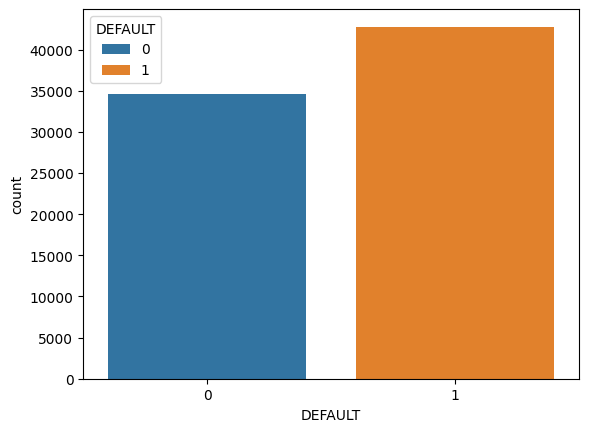

In [195]:
sns.countplot(data = df, x = "DEFAULT", hue="DEFAULT")
target_count = df.DEFAULT.value_counts()
print('# Buen_Pagador:', target_count[0])
print('# 1 Mora_12M:', target_count[1])
print('Bad rate:', target_count[1]/(target_count[0]+target_count[1]))

### 2.3 Análsis Univariante

Examina cada variable individualmente para entender su distribución estadística.

**Estadísticas calculadas:**

| Estadístico | Qué indica |
|-------------|-------------|
| `count` | Número de valores no nulos |
| `mean` (media) | Valor promedio de la variable |
| `std` (desviación) | Dispersión de los datos |
| `min` / `max` | Rango de valores |
| `25%`, `50%`, `75%` | Percentiles (distribución) |

**Utilidad:**  
- Identificar variables con distribuciones asimétricas
- Detectar valores extremos potenciales
- Entender la escala de cada variable

In [196]:
df.select_dtypes(include=['number']).describe().transpose()

,count,mean,std,min,25%,50%,75%,max
DebtToIncome,77387.0,3.759551,4.730578,0.0000,0.00,0.00,10.000,10.00
FreeCash,77387.0,195.145532,848.487218,-2332.0000,0.00,0.00,269.055,158748.64
IncomeTotal,77387.0,1869.033183,6193.763738,0.0000,890.00,1300.00,2000.000,1012019.00
ExistingLiabilities,77387.0,3.351118,3.494341,0.0000,1.00,2.00,5.000,36.00
LiabilitiesTotal,77387.0,714.990199,44593.433495,0.0000,113.04,383.00,736.000,12400000.00
MonthlyPayment,77387.0,127.891554,125.996302,0.0000,43.07,101.13,162.110,2368.54
AppliedAmount,77387.0,2747.140470,2463.531975,31.9558,740.00,2125.00,3720.000,10632.00
Amount,77387.0,2473.451320,2163.046983,160.0000,740.00,2020.00,3185.000,10630.00
NoOfPreviousLoansBeforeLoan,77387.0,1.140902,2.028107,0.0000,0.00,0.00,1.000,24.00
AmountOfPreviousLoansBeforeLoan,77387.0,2172.872910,3889.677065,0.0000,0.00,0.00,3000.000,51104.00


### 2.4. Visualización de Datos

#### 2.4.1 Histogramas
**Propósito:** Visualizar la distribución de cada variable numérica.  
**Identifica:** Si la distribución es normal, sesgada o multimodal.

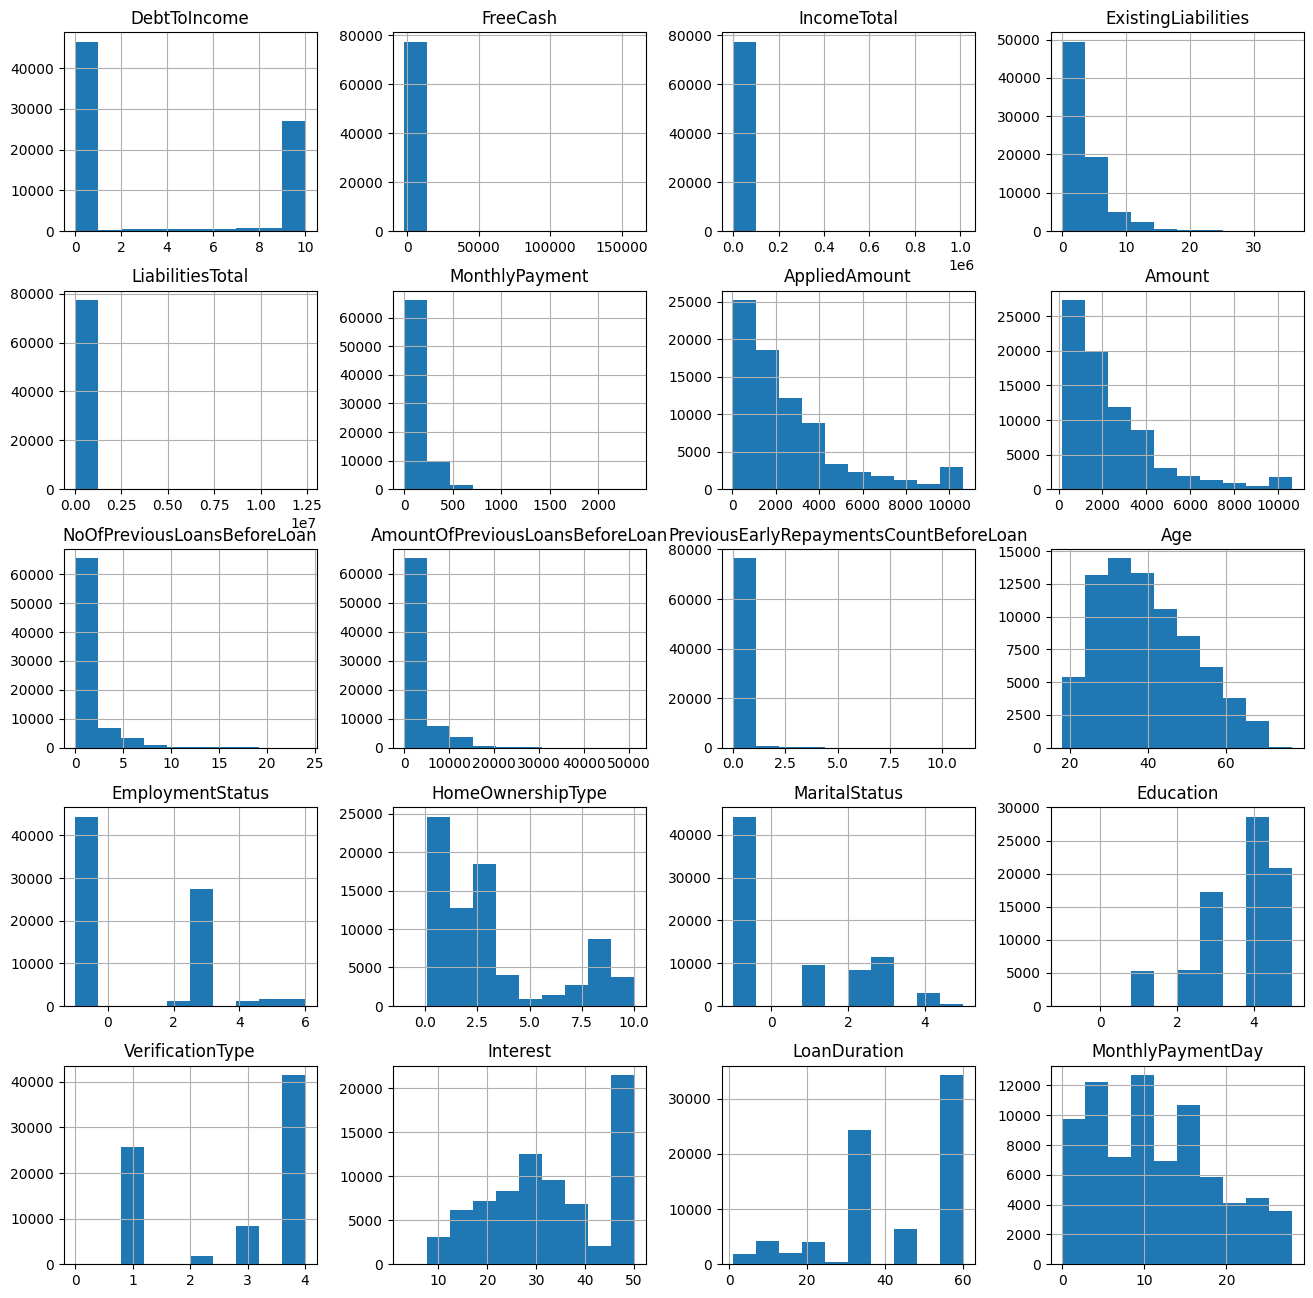

In [197]:
df.drop(columns = ['DEFAULT']).hist(figsize = (16, 16))
plt.show()

#### 2.4.2 Boxplots
**Propósito:** Detectar outliers de forma visual.  
**Identifica:** Valores atípicos que pueden distorsionar el modelo.

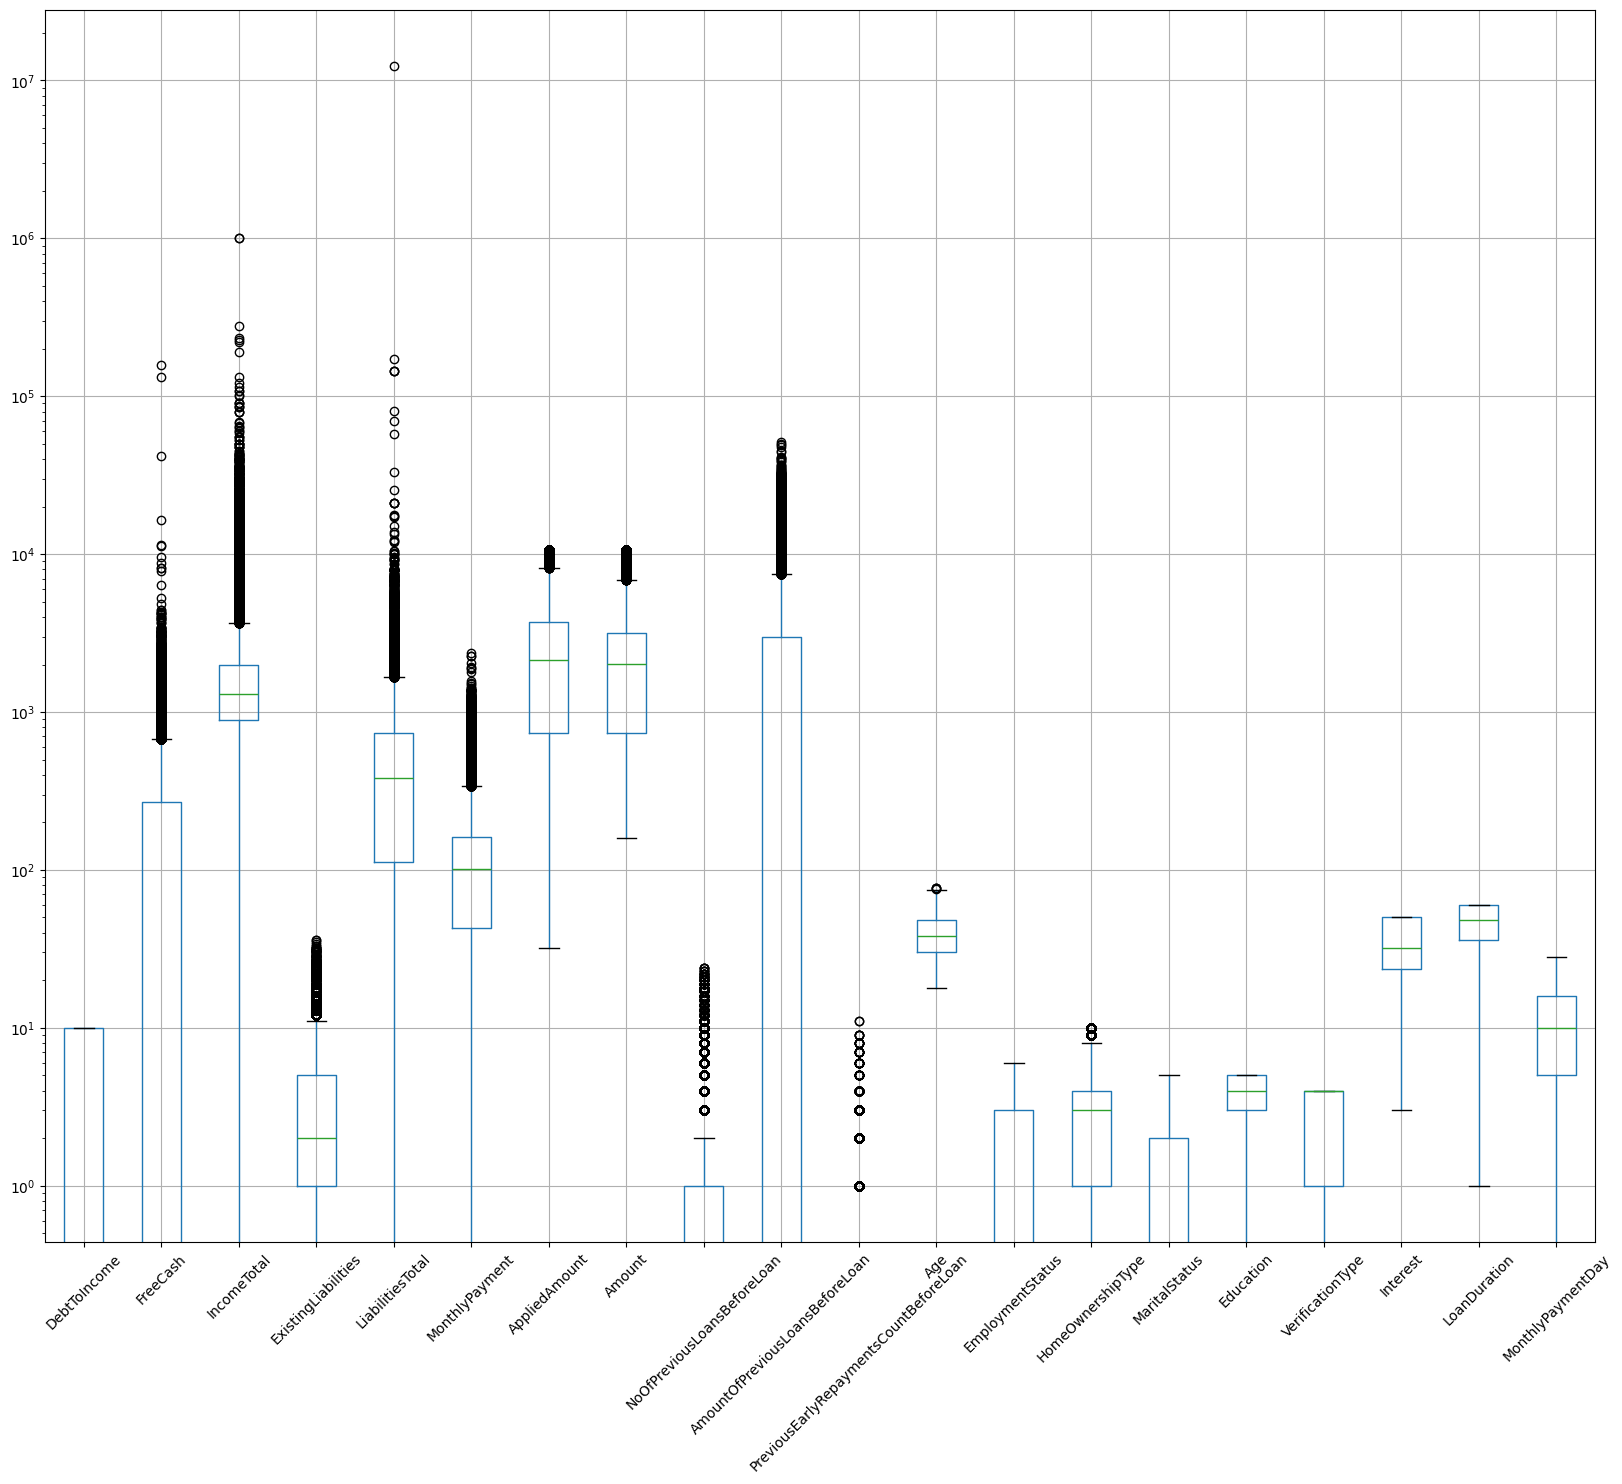

In [198]:
df.drop(columns = ['DEFAULT']).boxplot(figsize = (20, 16))
plt.yscale('log')
plt.xticks(rotation = 45)
plt.show()

#### 2.4.3 Función de Detección de Outliers por IQR
**Propósito:** Cuantificar automáticamente los outliers en cada variable.

**Cómo funciona:**
1. Calcula el rango intercuartil (IQR = Q3 - Q1)
2. Define límites: `Q1 - 1.5×IQR` (inferior) y `Q3 + 1.5×IQR` (superior)
3. Cuenta valores fuera de estos límites

In [199]:

def outliers_col(df):
    for columna in df.columns:
        
        if pd.api.types.is_numeric_dtype(df[columna]):

            serie = df[columna].dropna()

            q1 = stats.scoreatpercentile(serie, 25)
            q3 = stats.scoreatpercentile(serie, 75)

            iqr = q3 - q1
            lim_inf = q1 - 1.5 * iqr
            lim_sup = q3 + 1.5 * iqr

            n_outliers_inf = len(df[df[columna] < lim_inf])
            n_outliers_sup = len(df[df[columna] > lim_sup])

            print("{} | {} | {}".format(
                df[columna].name,
                n_outliers_inf,
                n_outliers_sup
            ))

In [200]:
outliers_col(df)

DebtToIncome | 0 | 0
FreeCash | 1 | 7614
IncomeTotal | 0 | 3921
ExistingLiabilities | 0 | 2599
LiabilitiesTotal | 0 | 3735
MonthlyPayment | 0 | 4619
AppliedAmount | 0 | 4194
Amount | 0 | 4019
NoOfPreviousLoansBeforeLoan | 0 | 11910
AmountOfPreviousLoansBeforeLoan | 0 | 7665
PreviousEarlyRepaymentsCountBeforeLoan | 0 | 4340
Age | 0 | 4
EmploymentStatus | 0 | 0
HomeOwnershipType | 0 | 3741
MaritalStatus | 0 | 0
Education | 3 | 0
VerificationType | 0 | 0
Interest | 0 | 0
LoanDuration | 0 | 0
MonthlyPaymentDay | 0 | 0
DEFAULT | 0 | 0


#### 2.4.4 Distribución por Clase de Default
**Propósito:** Comparar cómo se distribuyen las variables entre prestatarios que pagaron (0) y los que defaultieron (1).

**Utilidad:** Identificar qué variables tienen poder de discriminación entre clases.


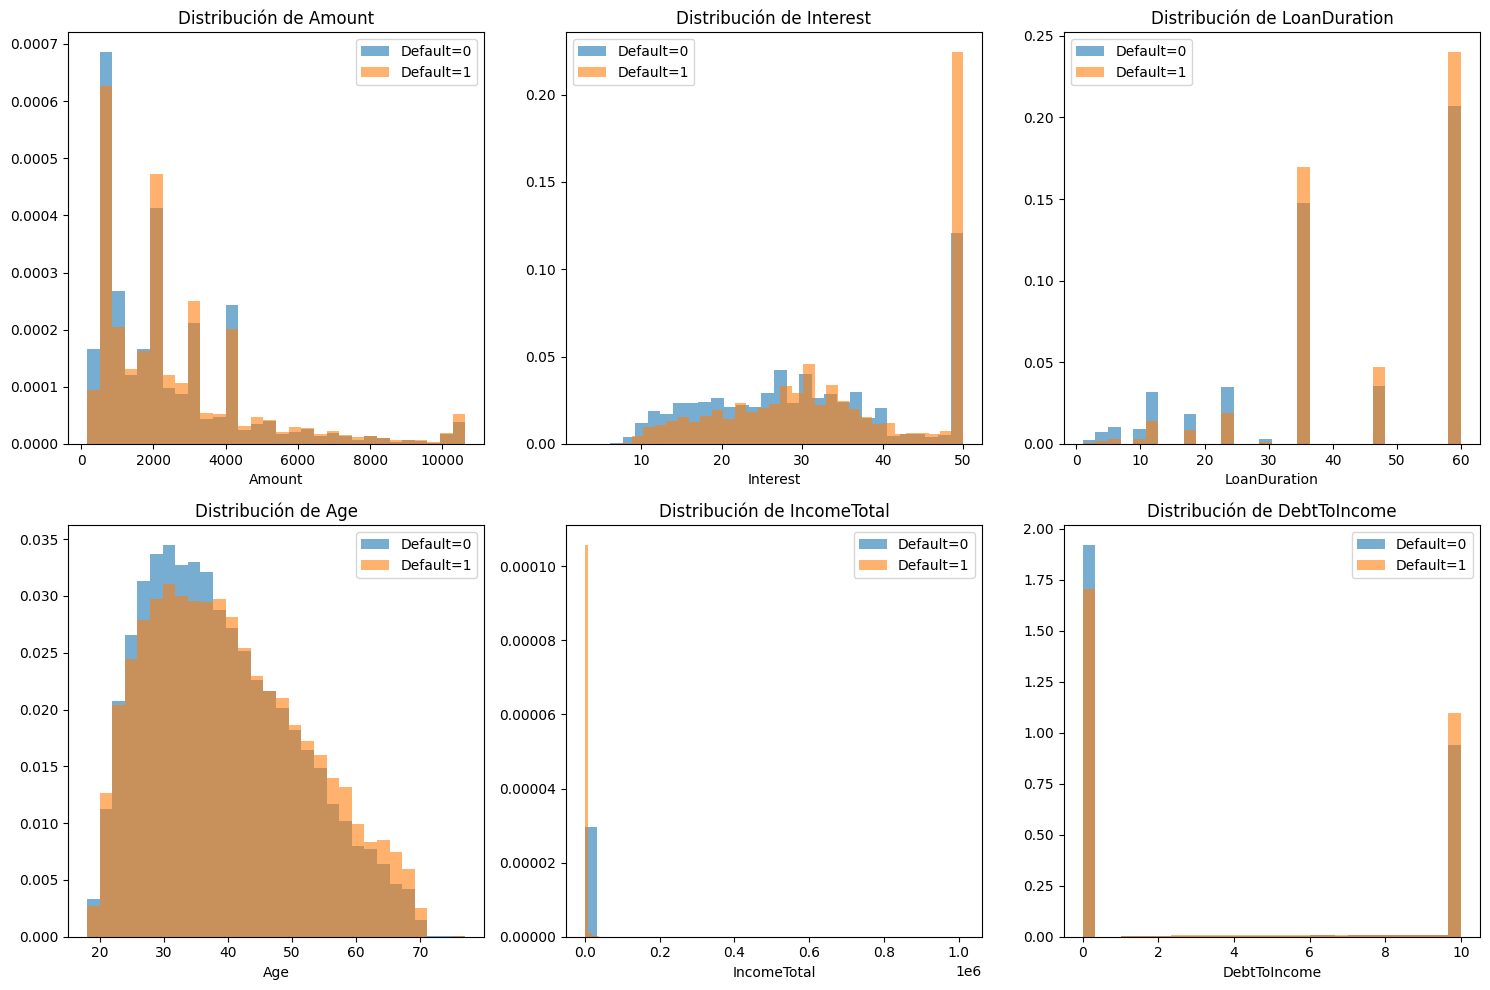

In [201]:
# Seleccionar principales features numéricas
main_features = ['Amount', 'Interest', 'LoanDuration', 'Age', 'IncomeTotal', 'DebtToIncome']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(main_features):
    if col in df.columns:
        # Histograma por clase de DEFAULT
        for default_value in [0, 1]:
            subset = df[df['DEFAULT'] == default_value]
            axes[i].hist(subset[col], bins=30, alpha=0.6, 
                        label=f'Default={default_value}', density=True)
        axes[i].set_title(f'Distribución de {col}')
        axes[i].set_xlabel(col)
        axes[i].legend()
    else:
        axes[i].set_visible(False)

plt.tight_layout()
plt.show()

## 3. Ingeniería de Características (Feature Engineering)

### Descripción de la Sección

La ingeniería de características transforma los datos crudos en un formato óptimo para los algoritmos de machine learning. Esta sección incluye: división train/test, tratamiento de valores nulos, codificación de variables categóricas, manejo de outliers y escalamiento.

### 3.1. Tratamiento de Missing

Identifica y rellena los valores faltantes en el dataset.

**Estrategias implementadas:**

| Tipo de variable | Método de imputación | Razón |
|------------------|---------------------|-------|
| Numérica | Mediana | Robusto ante outliers |
| Categórica | Moda (valor más frecuente) | Mantiene la distribución original |

**División Train/Test:**
- **Proporción:** 70% entrenamiento, 30% prueba
- **Estratificación:** Mantiene la misma proporción de DEFAULT en ambos conjuntos
- **Random State:** Fijo (42) para reproducibilidad

In [202]:
# Para partir las bases
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [203]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop("DEFAULT", axis=1),
    df["DEFAULT"],
    test_size=0.3,
    random_state=0,
    stratify=df["DEFAULT"] #este punto es importante para asegurar un adecuado muestreo de la variable objetivo
)

X_train.shape, X_test.shape

((54170, 22), (23217, 22))

In [204]:
# Comprobación de la proporción de Y en train
y_train.value_counts()[1]/(y_train.value_counts()[0]+y_train.value_counts()[1])

np.float64(0.5529444341886653)

In [205]:
# Comprobación de la proporción de Y en test
y_test.value_counts()[1]/(y_test.value_counts()[0]+y_test.value_counts()[1])

np.float64(0.5529138131541543)

##### 3.1.1. Variables Númericas

In [206]:
# Revisión de la proporción de nulos por variable
X_train.isnull().mean().where(X_train.isnull().mean()>0)

DebtToIncome                             NaN
FreeCash                                 NaN
IncomeTotal                              NaN
ExistingLiabilities                      NaN
LiabilitiesTotal                         NaN
MonthlyPayment                           NaN
AppliedAmount                            NaN
Amount                                   NaN
NoOfPreviousLoansBeforeLoan              NaN
AmountOfPreviousLoansBeforeLoan          NaN
PreviousEarlyRepaymentsCountBeforeLoan   NaN
Rating                                   NaN
Age                                      NaN
EmploymentStatus                         NaN
EmploymentDurationCurrentEmployer        NaN
HomeOwnershipType                        NaN
MaritalStatus                            NaN
Education                                NaN
VerificationType                         NaN
Interest                                 NaN
LoanDuration                             NaN
MonthlyPaymentDay                        NaN
dtype: flo

##### 3.1.2. Variables Categoricas

In [207]:
var_cat = X_train.select_dtypes(exclude = ["number"])
var_cat.isnull().mean().where(var_cat.isnull().mean()>0)

Rating                              NaN
EmploymentDurationCurrentEmployer   NaN
dtype: float64

##### 02.01.03. Tratamiento de Variables poco Frecuente

In [208]:
from sklearn.pipeline import Pipeline
from feature_engine.imputation import MeanMedianImputer, CategoricalImputer
from feature_engine.encoding import OneHotEncoder as FE_OneHotEncoder
from feature_engine.wrappers import SklearnTransformerWrapper
from feature_engine.creation import CyclicalFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from feature_engine.encoding import RareLabelEncoder
from feature_engine.outliers import Winsorizer
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer

In [209]:
cat_cols=['Rating','EmploymentDurationCurrentEmployer']

In [210]:
# Examinemos esto en la muestra de train
for col in cat_cols:
    print('variable: ', col, ' nro de categorias: ', X_train[col].nunique())

variable:  Rating  nro de categorias:  8
variable:  EmploymentDurationCurrentEmployer  nro de categorias:  9


In [211]:
#Examinemos esto en la muestra de test
for col in cat_cols:
    print('variable: ', col, ' nro de categorias: ', X_test[col].nunique())

variable:  Rating  nro de categorias:  8
variable:  EmploymentDurationCurrentEmployer  nro de categorias:  9


In [212]:
# Analicemos la variable Ratint Preliminar
unique_to_train_set = [x for x in X_train.Rating.unique() if x not in X_test.Rating.unique()]
print('El nro de categorias que aparecen en el train y no en el test es', len(unique_to_train_set))
unique_to_test_set = [x for x in X_test.Rating.unique() if x not in X_train.Rating.unique()]
print('El nro de categorias que aparecen en el test y no en el train es', len(unique_to_test_set))

El nro de categorias que aparecen en el train y no en el test es 0
El nro de categorias que aparecen en el test y no en el train es 0


In [213]:
# Analicemos la variable Ratint Preliminar
unique_to_train_set = [x for x in X_train.EmploymentDurationCurrentEmployer.unique() if x not in X_test.EmploymentDurationCurrentEmployer.unique()]
print('El nro de categorias que aparecen en el train y no en el test es', len(unique_to_train_set))
unique_to_test_set = [x for x in X_test.EmploymentDurationCurrentEmployer.unique() if x not in X_train.EmploymentDurationCurrentEmployer.unique()]
print('El nro de categorias que aparecen en el test y no en el train es', len(unique_to_test_set))

El nro de categorias que aparecen en el train y no en el test es 0
El nro de categorias que aparecen en el test y no en el train es 0


In [214]:
def mapear(df):
    df = df.copy()
    mapa_antiguedad = {
        'TrialPeriod': 0.25,
        'UpTo1Year': 0.5,
        'UpTo2Years': 1.5,
        'UpTo3Years': 2.5,
        'UpTo4Years': 3.5,
        'UpTo5Years': 4.5,
        'MoreThan5Years': 8.0,
        'Retiree': 10,       # Modifica este valor según tu criterio (ver nota)
        'Other': 3.0          # Valor neutral (mediana de la escala)
    }
    df['EmploymentDurationCurrentEmployer'] = df['EmploymentDurationCurrentEmployer'].replace(mapa_antiguedad)
    df['EmploymentDurationCurrentEmployer'] = df['EmploymentDurationCurrentEmployer'].astype(float)
    mapa_rating = {
        'AA': 1, 'A': 2, 'B': 3,
        'C': 4, 'D': 5, 'E': 6,
        'F': 7, 'HR': 8
    }
    df['Rating'] = df['Rating'].replace(mapa_rating)
    df['Rating'] = df['Rating'].astype(float)
    df['HomeOwnershipType'] = df['HomeOwnershipType'].astype(str)
    
    df['MaritalStatus'] = df['MaritalStatus'].astype(str)
    
    return df


In [215]:
pipe_1 = Pipeline([
    # Paso 1: Mapear antigüedad
    ('mapear_duration', FunctionTransformer(mapear))
])

In [216]:
pipe_1.fit(X_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('mapear_duration', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['DebtToIncome','FreeCash','IncomeTotal',...,'Interest','LoanDuration', 'MonthlyPaymentDay']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function map...0020F3A303A00>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False


In [217]:
X_train_t = pipe_1.transform(X_train)
X_test_t = pipe_1.transform(X_test)

In [218]:
X_train_t.EmploymentDurationCurrentEmployer.value_counts()

EmploymentDurationCurrentEmployer
8.00     21122
0.50     10100
4.50      9638
1.50      3883
2.50      3151
10.00     2324
3.50      2135
3.00      1390
0.25       427
Name: count, dtype: int64

In [219]:
pipe_2 = Pipeline([
    # Paso 1: Mapear antigüedad
    ('mapear_duration', FunctionTransformer(mapear)),
    
    # Paso 2: Valores raro
    ("rare_encoder", RareLabelEncoder(tol=0.001,n_categories=5,variables=["HomeOwnershipType","MaritalStatus"]))
    
])

In [220]:
pipe_2.fit(X_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('mapear_duration', ...), ('rare_encoder', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['DebtToIncome','FreeCash','IncomeTotal',...,'Interest','LoanDuration', 'MonthlyPaymentDay']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function map...0020F3A303A00>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False


In [221]:
X_train_t = pipe_2.transform(X_train)
X_test_t = pipe_2.transform(X_test)

### 3.2. Tratamiendo de Outlayers 

Detecta y limita valores extremos que pueden distorsionar el modelo.

**Método utilizado: Winsorización (Capping)**

| Parámetro | Valor | Significado |
|-----------|-------|-------------|
| `capping_method` | quantiles | Basado en percentiles |
| `fold` | 0.01 | Limita al percentil 1 y 99 |
| `tail` | both | Aplica a ambos extremos |

**Ventaja:** No elimina datos, solo los acota a rangos razonables.

In [222]:
X_train_t.describe().T

,count,mean,std,min,25%,50%,75%,max
DebtToIncome,54170.0,3.763953,4.731559,0.0000,0.000,0.00,10.0000,10.00
FreeCash,54170.0,191.021032,415.458392,-2332.0000,0.000,0.00,267.8875,41934.36
IncomeTotal,54170.0,1884.514748,7014.997986,0.0000,890.000,1300.00,2000.0000,1012019.00
ExistingLiabilities,54170.0,3.338601,3.481504,0.0000,1.000,2.00,5.0000,36.00
LiabilitiesTotal,54170.0,551.698373,1241.885937,0.0000,112.345,383.00,736.0000,172510.00
MonthlyPayment,54170.0,128.097409,126.358259,0.0000,43.270,101.13,162.6475,2368.54
AppliedAmount,54170.0,2751.467023,2470.471420,31.9558,740.000,2125.00,3720.0000,10632.00
Amount,54170.0,2478.072089,2171.259127,160.0000,740.000,2020.00,3185.0000,10630.00
NoOfPreviousLoansBeforeLoan,54170.0,1.133819,2.023861,0.0000,0.000,0.00,1.0000,24.00
AmountOfPreviousLoansBeforeLoan,54170.0,2156.603535,3871.249961,0.0000,0.000,0.00,2990.0000,51104.00


In [223]:
outliers_col(X_train_t)

DebtToIncome | 0 | 0
FreeCash | 1 | 5369
IncomeTotal | 0 | 2755
ExistingLiabilities | 0 | 1795
LiabilitiesTotal | 0 | 2586
MonthlyPayment | 0 | 3197
AppliedAmount | 0 | 2956
Amount | 0 | 2842
NoOfPreviousLoansBeforeLoan | 0 | 8237
AmountOfPreviousLoansBeforeLoan | 0 | 5337
PreviousEarlyRepaymentsCountBeforeLoan | 0 | 3047
Rating | 0 | 0
Age | 0 | 3
EmploymentStatus | 0 | 0
EmploymentDurationCurrentEmployer | 0 | 0
Education | 2 | 0
VerificationType | 0 | 0
Interest | 0 | 0
LoanDuration | 0 | 0
MonthlyPaymentDay | 0 | 0


In [224]:
num_cols = [
    'DebtToIncome','FreeCash','IncomeTotal','ExistingLiabilities','LiabilitiesTotal','MonthlyPayment',
    'AppliedAmount','Amount','NoOfPreviousLoansBeforeLoan','AmountOfPreviousLoansBeforeLoan',
    'PreviousEarlyRepaymentsCountBeforeLoan','Rating','Age','EmploymentStatus',
    'EmploymentDurationCurrentEmployer','Education','VerificationType','Interest',
    'LoanDuration','MonthlyPaymentDay'
]

In [225]:

pipe_3 = Pipeline([
    # Paso 1: Mapear antigüedad
    ('mapear_duration', FunctionTransformer(mapear)),

    # Paso 2: Valores raro
    ("rare_encoder", RareLabelEncoder(tol=0.001,n_categories=5,variables=["HomeOwnershipType","MaritalStatus"])),
    
    # Paso 3: Velores Outlayers
    ("capper", Winsorizer(variables=num_cols, capping_method="quantiles", tail="both", fold=0.01)),
])


In [226]:
pipe_3.fit(X_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('mapear_duration', ...), ('rare_encoder', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['DebtToIncome','FreeCash','IncomeTotal',...,'Interest','LoanDuration', 'MonthlyPaymentDay']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function map...0020F3A303A00>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False


In [227]:
X_train_t = pipe_3.transform(X_train)
X_test_t = pipe_3.transform(X_test)

In [228]:
outliers_col(X_train_t)

DebtToIncome | 0 | 0
FreeCash | 0 | 5369
IncomeTotal | 0 | 2755
ExistingLiabilities | 0 | 1795
LiabilitiesTotal | 0 | 2586
MonthlyPayment | 0 | 3197
AppliedAmount | 0 | 2956
Amount | 0 | 2842
NoOfPreviousLoansBeforeLoan | 0 | 8237
AmountOfPreviousLoansBeforeLoan | 0 | 5337
PreviousEarlyRepaymentsCountBeforeLoan | 0 | 3047
Rating | 0 | 0
Age | 0 | 0
EmploymentStatus | 0 | 0
EmploymentDurationCurrentEmployer | 0 | 0
Education | 0 | 0
VerificationType | 0 | 0
Interest | 0 | 0
LoanDuration | 0 | 0
MonthlyPaymentDay | 0 | 0


In [229]:
# Analicemos la variable PROFESION
unique_to_train_set = [x for x in X_train_t.Rating.unique() if x not in X_test_t.Rating.unique()]
print('El nro de categorias que aparecen en el train y no en el test es', len(unique_to_train_set))
unique_to_test_set = [x for x in X_test_t.Rating.unique() if x not in X_train_t.Rating.unique()]
print('El nro de categorias que aparecen en el test y no en el train es', len(unique_to_test_set))

El nro de categorias que aparecen en el train y no en el test es 0
El nro de categorias que aparecen en el test y no en el train es 0


In [230]:
X_train_t.Rating.value_counts()

Rating
7.0    12943
8.0     9178
6.0     8559
5.0     8254
4.0     7259
3.0     4856
2.0     1966
1.0     1155
Name: count, dtype: int64

In [231]:
X_train_t.EmploymentDurationCurrentEmployer.value_counts()

EmploymentDurationCurrentEmployer
8.0     21122
0.5     10527
4.5      9638
1.5      3883
2.5      3151
10.0     2324
3.5      2135
3.0      1390
Name: count, dtype: int64

### 3.3. Escalonamiento

Estandariza las variables numéricas para que estén en escalas comparables.

**Escalador utilizado: RobustScaler**

| Característica | Valor |
|----------------|-------|
| Centro | Mediana (no media) |
| Escala | Rango intercuartil (IQR) |
| Ventaja | Resistente a outliers |

**Fórmula:** `X_scaled = (X - median) / IQR`

In [232]:
pipe_4 = Pipeline([
    # Paso 1: Mapear antigüedad
    ('mapear_duration', FunctionTransformer(mapear)),

    # Paso 2: Valores raro
    ("rare_encoder", RareLabelEncoder(tol=0.001,n_categories=5,variables=["HomeOwnershipType","MaritalStatus"])),
    
    # Paso 3: Velores Outlayers
    ("capper", Winsorizer(variables=num_cols, capping_method="quantiles", tail="both", fold=0.01)),
    
    # Paso 4: Escalonamiento
    ("scaler", ColumnTransformer(transformers=[('e', RobustScaler(), num_cols)],remainder='passthrough',verbose_feature_names_out=False).set_output(transform="pandas")),
    
    
])

In [233]:
pipe_4.fit(X_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('mapear_duration', ...), ('rare_encoder', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['DebtToIncome','FreeCash','IncomeTotal',...,'Interest','LoanDuration', 'MonthlyPaymentDay']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function map...0020F3A303A00>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False


### 3.4. Usando One Hot

Convierte variables categóricas en formato numérico para que los algoritmos puedan procesarlas.

**Variables codificadas:**
- `HomeOwnershipType` (tipo de vivienda)
- `MaritalStatus` (estado civil)

**Parámetros:**
- `drop_last=True` → Evita multicolinealidad (elimina una categoría de referencia)

In [234]:
pipe_5 = Pipeline([
    # Paso 1: Mapear antigüedad
    ('mapear_duration', FunctionTransformer(mapear)),

    # Paso 2: Valores raro
    ("rare_encoder", RareLabelEncoder(tol=0.001,n_categories=5,variables=["HomeOwnershipType","MaritalStatus"])),
    
    # Paso 3: Velores Outlayers
    ("capper", Winsorizer(variables=num_cols, capping_method="quantiles", tail="both", fold=0.01)),
    
    # Paso 4: Escalonamiento
    ("scaler", ColumnTransformer(transformers=[('e', RobustScaler(), num_cols)],remainder='passthrough',verbose_feature_names_out=False).set_output(transform="pandas")),
    
    # Paso 5: Usando OneHotEncoder
    ('onehot', FE_OneHotEncoder(variables=['HomeOwnershipType', 'MaritalStatus'], drop_last=True))
    
])

### 3.5 Pipeline de Preprocesamiento

Encadena todos los pasos anteriores en una sola tubería reproducible.

**Estructura del Pipeline:**

In [235]:
pipe_5.fit(X_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('mapear_duration', ...), ('rare_encoder', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['DebtToIncome','FreeCash','IncomeTotal',...,'Interest','LoanDuration', 'MonthlyPaymentDay']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function map...0020F3A303A00>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False


In [236]:
X_train_t = pipe_5.transform(X_train)
X_test_t = pipe_5.transform(X_test)

## 4. Modelo Propuesto

### Descripción de la Sección

Esta sección entrena y evalúa modelos de machine learning para predecir el default. Se comparan dos algoritmos: Random Forest (baseline) y XGBoost (optimizado), seleccionando el de mejor rendimiento.

### 4.1 Modelo Baseline: Random Forest
  
Entrena un modelo Random Forest como punto de referencia inicial.

**Cómo funciona Random Forest:**
1. Crea múltiples árboles de decisión con submuestras aleatorias
2. Cada árbol vota por una clase
3. La clase con más votos es la predicción final


**Parámetros utilizados:**

| Parámetro | Valor | Propósito |
|-----------|-------|-----------|
| `n_estimators` | 100 | Número de árboles |
| `max_depth` | 10 | Profundidad máxima (evita overfitting) |
| `random_state` | 42 | Reproducibilidad |
| `n_jobs` | -1 | Usar todos los procesadores |

**Métricas calculadas:**
- **Accuracy:** Proporción de aciertos totales
- **Precision:** De los que predijo default, ¿cuántos realmente lo fueron?
- **Recall:** De los que realmente defaultieron, ¿cuántos detectó?
- **F1-Score:** Media armónica de precisión y recall
- **AUC:** Capacidad de discriminar entre clases
- **Gini:** 2×AUC - 1 (poder de separación)
- **KS:** Máxima diferencia entre tasas de acierto

In [237]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

# 1. Aplicar el pipeline a los datos
X_train_t = pipe_5.transform(X_train)
X_test_t = pipe_5.transform(X_test)

print("="*50)
print("DATOS TRANSFORMADOS")
print("="*50)
print(f"Train shape: {X_train_t.shape}")
print(f"Test shape: {X_test_t.shape}")
print(f"Columnas: {X_train_t.columns.tolist()[:10]}...")

# 2. Entrenar modelo
modelo = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

modelo.fit(X_train_t, y_train)
print("\n✅ Modelo Random Forest entrenado")

# 3. Predecir
y_pred = modelo.predict(X_test_t)
y_pred_proba = modelo.predict_proba(X_test_t)[:, 1]

# 4. Evaluar
print("\n" + "="*50)
print("RESULTADOS DEL MODELO")
print("="*50)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"🎯 Accuracy:  {accuracy:.4f}")
print(f"📌 Precision: {precision:.4f}")
print(f"🔍 Recall:    {recall:.4f}")
print(f"⚖️  F1-Score:  {f1:.4f}")
print(f"📈 AUC:       {auc:.4f}")

# 5. Matriz de confusión
print("\n📊 MATRIZ DE CONFUSIÓN:")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(f"\nInterpretación:")
print(f"  Verdaderos Negativos: {cm[0,0]:,}")
print(f"  Falsos Positivos:     {cm[0,1]:,}")
print(f"  Falsos Negativos:     {cm[1,0]:,}")
print(f"  Verdaderos Positivos: {cm[1,1]:,}")

# 6. Importancia de features
importancias = pd.DataFrame({
    'feature': X_train_t.columns,
    'importance': modelo.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 TOP 10 FEATURES MÁS IMPORTANTES:")
print(importancias.head(10).to_string(index=False))

from scipy.stats import ks_2samp

ks = ks_2samp(
    y_pred_proba[y_test==0],
    y_pred_proba[y_test==1]
)

print("KS:", round(ks.statistic,4))


gini = 2*auc - 1
print("Gini:", round(gini,4))


DATOS TRANSFORMADOS
Train shape: (54170, 36)
Test shape: (23217, 36)
Columnas: ['DebtToIncome', 'FreeCash', 'IncomeTotal', 'ExistingLiabilities', 'LiabilitiesTotal', 'MonthlyPayment', 'AppliedAmount', 'Amount', 'NoOfPreviousLoansBeforeLoan', 'AmountOfPreviousLoansBeforeLoan']...

✅ Modelo Random Forest entrenado

RESULTADOS DEL MODELO
🎯 Accuracy:  0.6918
📌 Precision: 0.6897
🔍 Recall:    0.8045
⚖️  F1-Score:  0.7427
📈 AUC:       0.7541

📊 MATRIZ DE CONFUSIÓN:
[[ 5734  4646]
 [ 2510 10327]]

Interpretación:
  Verdaderos Negativos: 5,734
  Falsos Positivos:     4,646
  Falsos Negativos:     2,510
  Verdaderos Positivos: 10,327

📊 TOP 10 FEATURES MÁS IMPORTANTES:
          feature  importance
           Rating    0.146120
     LoanDuration    0.143479
   MonthlyPayment    0.113326
         Interest    0.097789
    AppliedAmount    0.054535
           Amount    0.048201
 LiabilitiesTotal    0.044826
      IncomeTotal    0.034262
         FreeCash    0.034233
MonthlyPaymentDay    0.033390
KS

### 4.2 Modelo Optimizado: XGBoost

Entrena un modelo XGBoost con hiperparámetros optimizados para superar al baseline.

**Cómo funciona XGBoost:**
1. Construye árboles secuencialmente
2. Cada árbol corrige errores del anterior
3. Incluye regularización para evitar overfitting


| Parámetro | Valor | Propósito |
|-----------|-------|-----------|
| `n_estimators` | 400 | Número de árboles (mayor que RF) |
| `max_depth` | 5 | Profundidad limitada (controla complejidad) |
| `learning_rate` | 0.03 | Tasa de aprendizaje (pequeña = mejor generalización) |
| `subsample` | 0.85 | Usa 85% de datos por árbol |
| `colsample_bytree` | 0.85 | Usa 85% de features por árbol |
| `reg_alpha` | 0.5 | Regularización L1 (reduce overfitting) |
| `reg_lambda` | 2 | Regularización L2 (reduce overfitting) |


In [238]:
# =============================================
# XGBOOST - MODELO AVANZADO
# =============================================

from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix)

# 1. Entrenar XGBoost
xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.5,
    reg_lambda=2,
    random_state=42,
    eval_metric='auc'
)

xgb_model.fit(X_train_t, y_train)

print("✅ Modelo XGBoost entrenado")

# 2. Predicciones
y_pred_xgb = xgb_model.predict(X_test_t)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_t)[:, 1]

# 3. Métricas
print("\n" + "="*50)
print("RESULTADOS - XGBOOST")
print("="*50)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print(f"🎯 Accuracy:  {accuracy_xgb:.4f}")
print(f"📌 Precision: {precision_xgb:.4f}")
print(f"🔍 Recall:    {recall_xgb:.4f}")
print(f"⚖️  F1-Score:  {f1_xgb:.4f}")
print(f"📈 AUC:       {auc_xgb:.4f}")

# 4. Matriz de confusión
print("\n📊 MATRIZ DE CONFUSIÓN - XGBOOST:")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(cm_xgb)

# 5. Comparación con Random Forest
print("\n" + "="*50)
print("COMPARACIÓN DE MODELOS")
print("="*50)
print(f"{'Métrica':<15} {'Random Forest':<15} {'XGBoost':<15} {'Diferencia':<15}")
print("-"*60)
print(f"{'Accuracy':<15} {accuracy:<15.4f} {accuracy_xgb:<15.4f} {(accuracy_xgb-accuracy)*100:+.2f}%")
print(f"{'Precision':<15} {precision:<15.4f} {precision_xgb:<15.4f} {(precision_xgb-precision)*100:+.2f}%")
print(f"{'Recall':<15} {recall:<15.4f} {recall_xgb:<15.4f} {(recall_xgb-recall)*100:+.2f}%")
print(f"{'F1-Score':<15} {f1:<15.4f} {f1_xgb:<15.4f} {(f1_xgb-f1)*100:+.2f}%")
print(f"{'AUC':<15} {auc:<15.4f} {auc_xgb:<15.4f} {(auc_xgb-auc)*100:+.2f}%")


gini_xgb = 2 * auc_xgb - 1
print("Gini XGBoost:", round(gini_xgb,4))

from scipy.stats import ks_2samp

ks_xgb = ks_2samp(
    y_pred_proba_xgb[y_test == 0],
    y_pred_proba_xgb[y_test == 1]
)

print("KS XGBoost:", round(ks_xgb.statistic,4))

✅ Modelo XGBoost entrenado

RESULTADOS - XGBOOST
🎯 Accuracy:  0.7015
📌 Precision: 0.6994
🔍 Recall:    0.8068
⚖️  F1-Score:  0.7493
📈 AUC:       0.7686

📊 MATRIZ DE CONFUSIÓN - XGBOOST:
[[ 5929  4451]
 [ 2480 10357]]

COMPARACIÓN DE MODELOS
Métrica         Random Forest   XGBoost         Diferencia     
------------------------------------------------------------
Accuracy        0.6918          0.7015          +0.97%
Precision       0.6897          0.6994          +0.97%
Recall          0.8045          0.8068          +0.23%
F1-Score        0.7427          0.7493          +0.66%
AUC             0.7541          0.7686          +1.45%
Gini XGBoost: 0.5372
KS XGBoost: 0.3904


In [239]:
# =============================================
# OVERFITTING
# =============================================

auc_train = roc_auc_score(
    y_train,
    xgb_model.predict_proba(X_train_t)[:,1]
)

print("\n" + "="*50)
print("ANÁLISIS DE SOBREAJUSTE")
print("="*50)
print(f"AUC Train: {auc_train:.4f}")
print(f"AUC Test : {auc_xgb:.4f}")
print(f"Gap      : {auc_train - auc_xgb:.4f}")


ANÁLISIS DE SOBREAJUSTE
AUC Train: 0.8011
AUC Test : 0.7686
Gap      : 0.0325


In [240]:
importancias_xgb = pd.DataFrame({
    'Variable': X_train_t.columns,
    'Importancia': xgb_model.feature_importances_
}).sort_values(
    'Importancia',
    ascending=False
)

print("\nTOP 20 VARIABLES MÁS IMPORTANTES")
print(importancias_xgb.head(20))


TOP 20 VARIABLES MÁS IMPORTANTES
                           Variable  Importancia
11                           Rating     0.136329
18                     LoanDuration     0.104630
5                    MonthlyPayment     0.054348
13                 EmploymentStatus     0.050590
17                         Interest     0.046733
0                      DebtToIncome     0.044264
30               MaritalStatus_-1.0     0.040485
16                 VerificationType     0.035406
6                     AppliedAmount     0.034902
15                        Education     0.032033
7                            Amount     0.029109
1                          FreeCash     0.028199
3               ExistingLiabilities     0.027593
9   AmountOfPreviousLoansBeforeLoan     0.026264
22            HomeOwnershipType_8.0     0.025749
8       NoOfPreviousLoansBeforeLoan     0.024477
19                MonthlyPaymentDay     0.021569
4                  LiabilitiesTotal     0.021348
21            HomeOwnershipType_3.0

In [241]:
df_score = pd.DataFrame({
    'score': y_pred_proba_xgb,
    'default': y_test.values
})

df_score['decil'] = pd.qcut(
    df_score['score'],
    10,
    labels=False,
    duplicates='drop'
) + 1

tabla_deciles = (
    df_score
    .groupby('decil')
    .agg(
        Clientes=('default','count'),
        Defaults=('default','sum'),
        PD=('default','mean')
    )
)

tabla_deciles['PD'] *= 100

print(tabla_deciles)

       Clientes  Defaults         PD
decil                               
1          2322       225   9.689922
2          2322       601  25.882860
3          2321       930  40.068936
4          2322      1170  50.387597
5          2322      1286  55.383290
6          2321      1446  62.300732
7          2322      1556  67.011197
8          2321      1708  73.588970
9          2322      1840  79.242033
10         2322      2075  89.362618


### 4.3 Selección del Mejor Modelo
  
Elige el modelo con mejor rendimiento basado en las métricas calculadas.

**Criterios de selección:**
1. Mayor AUC (poder predictivo)
2. Mayor Recall (capacidad de detectar defaults)
3. Menor gap de overfitting

COMPARACIÓN DE MODELOS DE CLASIFICACIÓN

📊 1. RANDOM FOREST
----------------------------------------
🎯 Accuracy:  0.6918
📌 Precision: 0.6897
🔍 Recall:    0.8045
⚖️  F1-Score:  0.7427
📈 AUC:       0.7541
📊 Gini:      0.5082
📐 KS:        0.3666

Matriz de Confusión RF:
  TN: 5,734  FP: 4,646
  FN: 2,510  TP: 10,327

📊 2. XGBOOST (Optimizado)
----------------------------------------
🎯 Accuracy:  0.7015
📌 Precision: 0.6994
🔍 Recall:    0.8068
⚖️  F1-Score:  0.7493
📈 AUC:       0.7686
📊 Gini:      0.5372
📐 KS:        0.3904

Matriz de Confusión XGB:
  TN: 5,929  FP: 4,451
  FN: 2,480  TP: 10,357

TABLA COMPARATIVA DE MODELOS
  Métrica  Random Forest  XGBoost  Diferencia
 Accuracy       0.691778 0.701469    0.009691
Precision       0.689708 0.699419    0.009711
   Recall       0.804471 0.806808    0.002337
 F1-Score       0.742682 0.749286    0.006603
      AUC       0.754095 0.768599    0.014504
     Gini       0.508191 0.537198    0.029007
       KS       0.366552 0.390387    0.023835


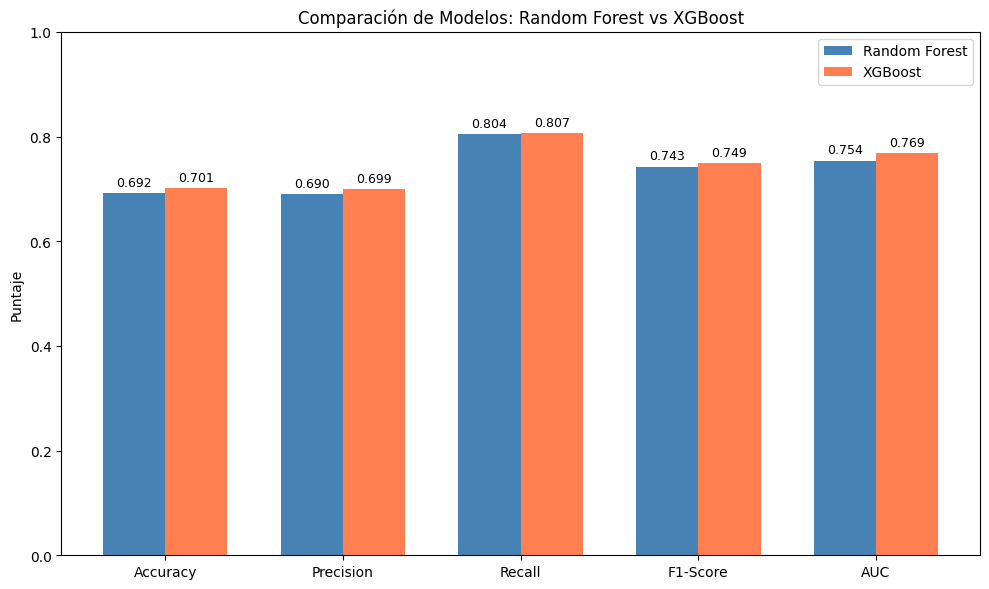

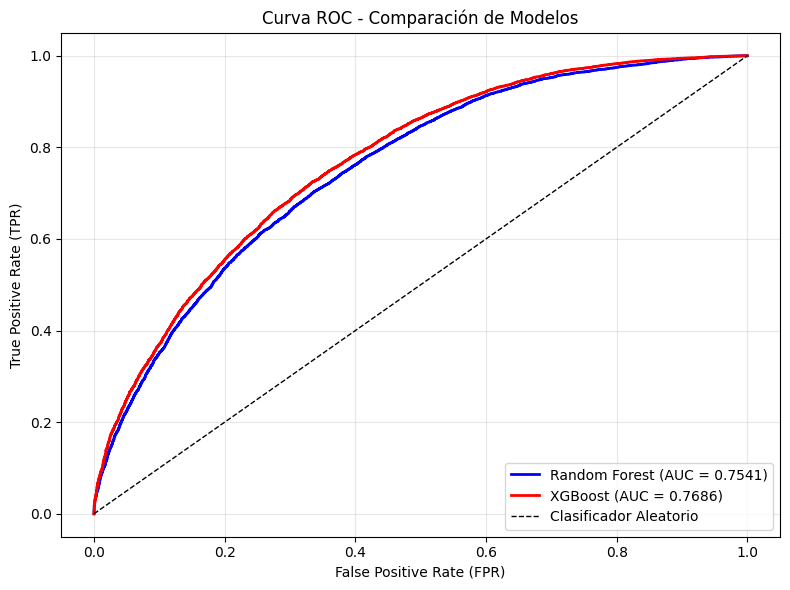


SELECCIÓN DEL MEJOR MODELO
🏆 MEJOR MODELO: XGBoost
   - AUC: 0.7686 (vs 0.7541 de Random Forest)
   - Recall: 0.8068 (vs 0.8045 de Random Forest)
   - Mejora en AUC: +1.45%
   - Mejora en Recall: +0.23%

✅ Tabla comparativa guardada en: artifacts/comparacion_modelos.csv
✅ Métricas del mejor modelo guardadas

RESUMEN DE LA COMPARACIÓN

📊 RANDOM FOREST:
   - AUC: 0.7541
   - Recall: 0.8045
   - Precision: 0.6897

📊 XGBOOST (Optimizado):
   - Parámetros: n_estimators=400, max_depth=5, learning_rate=0.03
   - AUC: 0.7686
   - Recall: 0.8068
   - Precision: 0.6994

✅ MODELO SELECCIONADO PARA EL PROYECTO: XGBOOST
   - AUC: 0.7686
   - Recall: 0.8068

✅ COMPARACIÓN DE MODELOS COMPLETADA


In [242]:
# =============================================
# COMPARACIÓN DE MODELOS: RANDOM FOREST vs XGBOOST
# =============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from scipy.stats import ks_2samp

print("="*60)
print("COMPARACIÓN DE MODELOS DE CLASIFICACIÓN")
print("="*60)

# =============================================
# 1. RANDOM FOREST (con tus parámetros)
# =============================================

print("\n📊 1. RANDOM FOREST")
print("-"*40)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_t, y_train)

# Predicciones Random Forest
y_pred_rf = rf_model.predict(X_test_t)
y_proba_rf = rf_model.predict_proba(X_test_t)[:, 1]

# Métricas Random Forest
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_proba_rf)
rf_gini = 2 * rf_auc - 1
rf_ks = ks_2samp(y_proba_rf[y_test==0], y_proba_rf[y_test==1])

print(f"🎯 Accuracy:  {rf_accuracy:.4f}")
print(f"📌 Precision: {rf_precision:.4f}")
print(f"🔍 Recall:    {rf_recall:.4f}")
print(f"⚖️  F1-Score:  {rf_f1:.4f}")
print(f"📈 AUC:       {rf_auc:.4f}")
print(f"📊 Gini:      {rf_gini:.4f}")
print(f"📐 KS:        {rf_ks.statistic:.4f}")

cm_rf = confusion_matrix(y_test, y_pred_rf)
print(f"\nMatriz de Confusión RF:")
print(f"  TN: {cm_rf[0,0]:,}  FP: {cm_rf[0,1]:,}")
print(f"  FN: {cm_rf[1,0]:,}  TP: {cm_rf[1,1]:,}")

# =============================================
# 2. XGBOOST (CON TUS PARÁMETROS OPTIMIZADOS)
# =============================================

print("\n📊 2. XGBOOST (Optimizado)")
print("-"*40)

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.5,
    reg_lambda=2,
    random_state=42,
    eval_metric='auc'
)

xgb_model.fit(X_train_t, y_train)

# Predicciones XGBoost
y_pred_xgb = xgb_model.predict(X_test_t)
y_proba_xgb = xgb_model.predict_proba(X_test_t)[:, 1]

# Métricas XGBoost
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_proba_xgb)
xgb_gini = 2 * xgb_auc - 1
xgb_ks = ks_2samp(y_proba_xgb[y_test==0], y_proba_xgb[y_test==1])

print(f"🎯 Accuracy:  {xgb_accuracy:.4f}")
print(f"📌 Precision: {xgb_precision:.4f}")
print(f"🔍 Recall:    {xgb_recall:.4f}")
print(f"⚖️  F1-Score:  {xgb_f1:.4f}")
print(f"📈 AUC:       {xgb_auc:.4f}")
print(f"📊 Gini:      {xgb_gini:.4f}")
print(f"📐 KS:        {xgb_ks.statistic:.4f}")

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(f"\nMatriz de Confusión XGB:")
print(f"  TN: {cm_xgb[0,0]:,}  FP: {cm_xgb[0,1]:,}")
print(f"  FN: {cm_xgb[1,0]:,}  TP: {cm_xgb[1,1]:,}")

# =============================================
# 3. TABLA COMPARATIVA
# =============================================

print("\n" + "="*60)
print("TABLA COMPARATIVA DE MODELOS")
print("="*60)

comparacion = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC', 'Gini', 'KS'],
    'Random Forest': [rf_accuracy, rf_precision, rf_recall, rf_f1, rf_auc, rf_gini, rf_ks.statistic],
    'XGBoost': [xgb_accuracy, xgb_precision, xgb_recall, xgb_f1, xgb_auc, xgb_gini, xgb_ks.statistic],
    'Diferencia': [xgb_accuracy - rf_accuracy, 
                   xgb_precision - rf_precision,
                   xgb_recall - rf_recall,
                   xgb_f1 - rf_f1,
                   xgb_auc - rf_auc,
                   xgb_gini - rf_gini,
                   xgb_ks.statistic - rf_ks.statistic]
})

print(comparacion.to_string(index=False))

# =============================================
# 4. GRÁFICO DE BARRAS COMPARATIVO
# =============================================

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
rf_values = [rf_accuracy, rf_precision, rf_recall, rf_f1, rf_auc]
xgb_values = [xgb_accuracy, xgb_precision, xgb_recall, xgb_f1, xgb_auc]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, rf_values, width, label='Random Forest', color='steelblue')
bars2 = ax.bar(x + width/2, xgb_values, width, label='XGBoost', color='coral')

ax.set_ylabel('Puntaje')
ax.set_title('Comparación de Modelos: Random Forest vs XGBoost')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1)

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../artifacts/comparacion_modelos_barras.png', dpi=150)
plt.show()

# =============================================
# 5. CURVA ROC COMPARATIVA
# =============================================

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, 'b-', linewidth=2, label=f'Random Forest (AUC = {rf_auc:.4f})')
plt.plot(fpr_xgb, tpr_xgb, 'r-', linewidth=2, label=f'XGBoost (AUC = {xgb_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador Aleatorio')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Curva ROC - Comparación de Modelos')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../artifacts/roc_curve_comparacion.png', dpi=150)
plt.show()

# =============================================
# 6. SELECCIÓN DEL MEJOR MODELO
# =============================================

print("\n" + "="*60)
print("SELECCIÓN DEL MEJOR MODELO")
print("="*60)

if xgb_auc > rf_auc:
    mejor_modelo = "XGBOOST"
    mejor_auc = xgb_auc
    mejor_recall = xgb_recall
    print(f"🏆 MEJOR MODELO: XGBoost")
    print(f"   - AUC: {xgb_auc:.4f} (vs {rf_auc:.4f} de Random Forest)")
    print(f"   - Recall: {xgb_recall:.4f} (vs {rf_recall:.4f} de Random Forest)")
    print(f"   - Mejora en AUC: +{(xgb_auc - rf_auc)*100:.2f}%")
    print(f"   - Mejora en Recall: +{(xgb_recall - rf_recall)*100:.2f}%")
else:
    mejor_modelo = "RANDOM FOREST"
    mejor_auc = rf_auc
    mejor_recall = rf_recall
    print(f"🏆 MEJOR MODELO: Random Forest")
    print(f"   - AUC: {rf_auc:.4f} (vs {xgb_auc:.4f} de XGBoost)")

# =============================================
# 7. GUARDAR RESULTADOS
# =============================================

comparacion.to_csv('../artifacts/comparacion_modelos.csv', index=False)
print("\n✅ Tabla comparativa guardada en: artifacts/comparacion_modelos.csv")

"""with open('../artifacts/mejor_modelo_metrics.txt', 'w') as f:
    f.write(f"Mejor Modelo: {mejor_modelo}\n")
    f.write(f"AUC: {mejor_auc:.4f}\n")
    f.write(f"Recall: {mejor_recall:.4f}\n")"""

print("✅ Métricas del mejor modelo guardadas")

# =============================================
# 8. RESUMEN FINAL
# =============================================

print("\n" + "="*60)
print("RESUMEN DE LA COMPARACIÓN")
print("="*60)
print(f"""
📊 RANDOM FOREST:
   - AUC: {rf_auc:.4f}
   - Recall: {rf_recall:.4f}
   - Precision: {rf_precision:.4f}

📊 XGBOOST (Optimizado):
   - Parámetros: n_estimators=400, max_depth=5, learning_rate=0.03
   - AUC: {xgb_auc:.4f}
   - Recall: {xgb_recall:.4f}
   - Precision: {xgb_precision:.4f}

✅ MODELO SELECCIONADO PARA EL PROYECTO: {mejor_modelo}
   - AUC: {mejor_auc:.4f}
   - Recall: {mejor_recall:.4f}
""")

print("✅ COMPARACIÓN DE MODELOS COMPLETADA")

## 5. Modelo LLM integrado

### Descripción de la Sección

Esta sección integra un modelo de lenguaje grande (Gemini de Google) para generar **resúmenes ejecutivos en lenguaje natural** del riesgo de cada préstamo, haciendo el modelo más interpretable para usuarios de negocio.

### 5.1. Generando una API

Configura la conexión con la API de Gemini para poder generar texto.

**Pasos:**
1. Guardar la API key en variable de entorno
2. Configurar el SDK de Google Generative AI
3. Verificar conexión

In [ ]:
import os
import google.generativeai as genai

# 1. Guarda tu clave directamente en la memoria del notebook
# (Reemplaza AIzaSy... por tu clave real de Google AI Studio)

os.environ["GEMINI_API_KEY"] = "AQUI_PON_TU_API"

# 2. Configura el SDK (buscará automáticamente la variable que guardamos arriba)
genai.configure()

# 3. Prueba de fuego
print("✅ Gemini configurado correctamente")

✅ Gemini configurado correctamente


### 5.2. Generando resumen de Riesgo

Crea una función que:
1. Calcula la probabilidad de default del préstamo (usando XGBoost)
2. Clasifica el préstamo como "Default" o "No Default"
3. Extrae variables clave del préstamo
4. Construye un prompt con toda la información
5. Envía el prompt a Gemini
6. Retorna el resumen generado

**Parámetros de entrada:**
- `fila`: Datos del préstamo
- `modelo_xgb`: Modelo XGBoost entrenado
- `pipeline`: Pipeline de preprocesamiento
- `prob_default` (opcional): Probabilidad precalculada

**Salida:**
- `probabilidad`: Probabilidad de default (0-1)
- `clasificacion`: "Default" o "No Default"
- `resumen`: Texto explicativo generado por Gemini

In [244]:
def generar_resumen_riesgo(fila, modelo_xgb, pipeline, prob_default=None):
    """
    Genera un resumen ejecutivo del riesgo del préstamo usando Gemini.
    
    Parámetros:
    - fila: una fila del dataset (features del préstamo)
    - modelo_xgb: tu modelo XGBoost entrenado
    - pipeline: pipeline de preprocesamiento
    - prob_default: (opcional) si ya la calculaste, pásala
    
    Retorna:
    - diccionario con probabilidad, clasificación y resumen
    """
    
    # 1. Calcular probabilidad de default (si no se pasó)
    if prob_default is None:
        fila_df = pd.DataFrame([fila])
        fila_procesada = pipeline.transform(fila_df)
        prob_default = modelo_xgb.predict_proba(fila_procesada)[0, 1]
    
    # 2. Determinar clasificación
    prediccion = "Default" if prob_default >= 0.5 else "No Default"
    
    # 3. Extraer variables importantes
    try:
        monto = fila.get('Amount', fila.get('AppliedAmount', 'N/A'))
        ingreso = fila.get('IncomeTotal', 'N/A')
        edad = fila.get('Age', 'N/A')
        deuda_ingreso = fila.get('DebtToIncome', 'N/A')
        proposito = fila.get('UseOfLoan', 'No especificado')
        interes = fila.get('Interest', 'N/A')
        duracion = fila.get('LoanDuration', 'N/A')
    except:
        monto = ingreso = edad = deuda_ingreso = proposito = interes = duracion = 'N/A'
    
    # 4. Crear prompt para Gemini
    prompt = f"""
Eres un analista de riesgos financieros.

DATOS DEL PRÉSTAMO:
- Monto: {monto} €
- Ingreso mensual: {ingreso} €
- Edad: {edad} años
- Deuda/Ingreso: {deuda_ingreso}
- Propósito: {proposito}
- Tasa interés: {interes}%
- Duración: {duracion} meses

RESULTADO DEL MODELO:
- Probabilidad de default: {prob_default:.2%}
- Clasificación: {prediccion}

INSTRUCCIONES:
Responde en español. Máximo 80 palabras.
Explica brevemente los factores de riesgo.
Si es alto riesgo (>50%), sugiere una acción.
Si es bajo riesgo (≤50%), explica por qué es seguro.

RESUMEN:
"""
    
    # 5. Llamar a Gemini
    model = genai.GenerativeModel('gemini-2.5-flash')
    response = model.generate_content(prompt)
    
    return {
        'probabilidad': prob_default,
        'clasificacion': prediccion,
        'resumen': response.text
    }

print("✅ Función creada")

✅ Función creada


### 5.3. Prueba de Ejemplo

Prueba la función con un préstamo real del conjunto de prueba.

**Muestra:**
- Probabilidad calculada
- Clasificación
- Resumen generado por Gemini

In [ ]:
# Probar con el primer préstamo
prestamo_ejemplo = X_test.iloc[0]

resultado = generar_resumen_riesgo(prestamo_ejemplo, xgb_model, pipe_5)

print("="*60)
print("RESUMEN DE RIESGO")
print("="*60)
print(f"Probabilidad: {resultado['probabilidad']:.2%}")
print(f"Clasificación: {resultado['clasificacion']}")
print("\n📝 GEMINI DICE:")
print(resultado['resumen'])

'prestamo_ejemplo = X_test.iloc[0]\n\nresultado = generar_resumen_riesgo(prestamo_ejemplo, xgb_model, pipe_5)\n\nprint("="*60)\nprint("RESUMEN DE RIESGO")\nprint("="*60)\nprint(f"Probabilidad: {resultado[\'probabilidad\']:.2%}")\nprint(f"Clasificación: {resultado[\'clasificacion\']}")\nprint("\n📝 GEMINI DICE:")\nprint(resultado[\'resumen\'])'

### 5.4. Multiples Codigos

Selecciona préstamos representativos por nivel de riesgo para análisis más completo.

**Criterios de selección:**

| Nivel | Rango de probabilidad | Cantidad |
|-------|----------------------|----------|
| Alto riesgo | > 70% | 2 préstamos |
| Medio riesgo | 30% - 70% | 2 préstamos |
| Bajo riesgo | < 30% | 2 préstamos |

In [ ]:
# Seleccionar 5 préstamos representativos
# (alto riesgo, medio riesgo, bajo riesgo)

# Calcular probabilidades para todo X_test
X_test_proc = pipe_5.transform(X_test)
probabilidades = xgb_model.predict_proba(X_test_proc)[:, 1]

# Crear DataFrame con resultados
resultados_test = X_test.copy()
resultados_test['prob_default'] = probabilidades
resultados_test['prediccion'] = (probabilidades >= 0.5).astype(int)

# Seleccionar ejemplos
alto_riesgo = resultados_test[resultados_test['prob_default'] > 0.7].head(1)
medio_riesgo = resultados_test[(resultados_test['prob_default'] >= 0.3) & (resultados_test['prob_default'] <= 0.7)].head(1)
bajo_riesgo = resultados_test[resultados_test['prob_default'] < 0.3].head(1)

# Unir todos
prestamos_selector = pd.concat([alto_riesgo, medio_riesgo, bajo_riesgo])

print(f"Seleccionados {len(prestamos_selector)} préstamos para análisis")
print(f"- Alto riesgo: {len(alto_riesgo)}")
print(f"- Medio riesgo: {len(medio_riesgo)}")
print(f"- Bajo riesgo: {len(bajo_riesgo)}")

Seleccionados 3 préstamos para análisis
- Alto riesgo: 1
- Medio riesgo: 1
- Bajo riesgo: 1


### 5.5 Generación de Resúmenes Múltiples

Genera resúmenes para cada préstamo seleccionado y los almacena.

**Proceso:**
1. Iterar sobre préstamos seleccionados
2. Generar resumen con Gemini
3. Almacenar en lista de diccionarios
4. Convertir a DataFrame
5. Guardar a CSV (opcional)

In [ ]:
resumenes = []

for idx, (i, fila) in enumerate(prestamos_selector.iterrows()):
    print(f"\n📋 Generando resumen {idx+1}/{len(prestamos_selector)}...")
    
    prob = fila['prob_default']
    
    resultado = generar_resumen_riesgo(fila, xgb_model, pipe_5, prob_default=prob)
    
    resumenes.append({
        'indice': i,
        'probabilidad': resultado['probabilidad'],
        'clasificacion': resultado['clasificacion'],
        'monto': fila.get('Amount', 'N/A'),
        'ingreso': fila.get('IncomeTotal', 'N/A'),
        'edad': fila.get('Age', 'N/A'),
        'deuda_ingreso': fila.get('DebtToIncome', 'N/A'),
        'resumen': resultado['resumen']
    })
    
    # Mostrar resumen
    print(f"  Prob: {resultado['probabilidad']:.2%} | {resultado['clasificacion']}")
    print(f"  {resultado['resumen'][:100]}...")

# Guardar a DataFrame
df_resumenes = pd.DataFrame(resumenes)

# Guardar a CSV
df_resumenes.to_csv('../artifacts/resumenes_gemini.csv', index=False)

print("\n" + "="*60)
print("✅ RESÚMENES GENERADOS Y GUARDADOS")
print("="*60)
print(f"Archivo: artifacts/resumenes_gemini.csv")
print(f"Total: {len(df_resumenes)} resúmenes")

'resumenes = []\n\nfor idx, (i, fila) in enumerate(prestamos_selector.iterrows()):\n    print(f"\n📋 Generando resumen {idx+1}/{len(prestamos_selector)}...")\n\n    prob = fila[\'prob_default\']\n\n    resultado = generar_resumen_riesgo(fila, xgb_model, pipe_5, prob_default=prob)\n\n    resumenes.append({\n        \'indice\': i,\n        \'probabilidad\': resultado[\'probabilidad\'],\n        \'clasificacion\': resultado[\'clasificacion\'],\n        \'monto\': fila.get(\'Amount\', \'N/A\'),\n        \'ingreso\': fila.get(\'IncomeTotal\', \'N/A\'),\n        \'edad\': fila.get(\'Age\', \'N/A\'),\n        \'deuda_ingreso\': fila.get(\'DebtToIncome\', \'N/A\'),\n        \'resumen\': resultado[\'resumen\']\n    })\n\n    # Mostrar resumen\n    print(f"  Prob: {resultado[\'probabilidad\']:.2%} | {resultado[\'clasificacion\']}")\n    print(f"  {resultado[\'resumen\'][:100]}...")\n\n# Guardar a DataFrame\ndf_resumenes = pd.DataFrame(resumenes)\n\n# Guardar a CSV\ndf_resumenes.to_csv(\'../artifa

## Resumen de lo que hace cada modelo

| Modelo | Tipo | Función | Cuándo se usa |
|--------|------|---------|---------------|
| **Random Forest** | Ensemble | Baseline de referencia | Comparar rendimiento inicial |
| **XGBoost** | Gradient Boosting | Modelo optimizado | Predicción final (mejor rendimiento) |
| **Gemini (LLM)** | Modelo de lenguaje | Generar resúmenes explicativos | Interpretabilidad para usuarios de negocio |

---


In [ ]:
# Tabla resumen
print("\n📊 TABLA RESUMEN DE PRÉSTAMOS ANALIZADOS")
print("="*80)

for i, row in df_resumenes.iterrows():
    print(f"\nPréstamo {i+1}:")
    print(f"  Probabilidad: {row['probabilidad']:.2%}")
    print(f"  Clasificación: {row['clasificacion']}")
    print(f"  Monto: {row['monto']} | Ingreso: {row['ingreso']} | Edad: {row['edad']}")
    print(f"  Resumen: {row['resumen'][:150]}...")


📊 TABLA RESUMEN DE PRÉSTAMOS ANALIZADOS

Préstamo 1:
  Probabilidad: 81.97%
  Clasificación: Default
  Monto: 10630.0 | Ingreso: 1640.0 | Edad: 33
  Resumen: **RESUMEN:**
Los factores de riesgo principales son una tasa de interés extremadamente alta (33.01%) y una probabilidad de impago del 81.97%. Aunque e...

Préstamo 2:
  Probabilidad: 72.44%
  Clasificación: Default
  Monto: 1590.0 | Ingreso: 630.0 | Edad: 40
  Resumen: RESUMEN:
Este préstamo presenta un **riesgo muy alto de impago (72.44%)**. Los factores clave son la **elevadísima tasa de interés (27.51%)** y una **...

Préstamo 3:
  Probabilidad: 59.86%
  Clasificación: Default
  Monto: 3325.0 | Ingreso: 780.0 | Edad: 34
  Resumen: El riesgo de impago es alto (59.86%), clasificando el préstamo como "Default". Los factores clave incluyen una probabilidad de impago elevada, una tas...

Préstamo 4:
  Probabilidad: 52.69%
  Clasificación: Default
  Monto: 885.0 | Ingreso: 936.0 | Edad: 23
  Resumen: El préstamo presenta un **alto r

## Flujo completo del proyecto